In [3]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the taxis dataset
df = sns.load_dataset("taxis")

# Display first 5 rows
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [4]:
# Step 2: Handling Missing Values

# Check missing values
print("Missing values before handling:")
print(df.isnull().sum())

# Identify numerical and categorical columns
numeric_cols = df.select_dtypes(include="number").columns
categorical_cols = df.select_dtypes(exclude="number").columns


Missing values before handling:
pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [10]:
# Fill numerical missing values with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Remove remaining rows with missing values
df = df.dropna()

# Check missing values after handling
print("\nMissing values after handling:")
print(df.isnull().sum())



Missing values after handling:
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


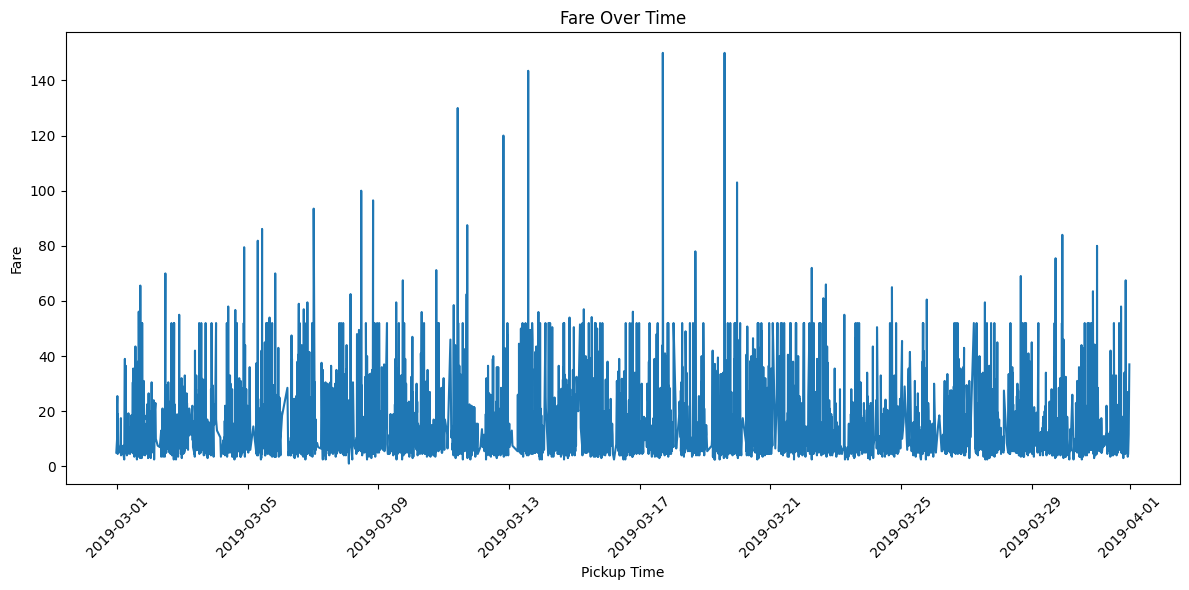

In [11]:
# STEP 3: VISUALIZATIONS
import matplotlib.pyplot as plt

# LINE CHART

df["pickup"] = pd.to_datetime(df["pickup"])
df = df.sort_values("pickup")

plt.figure(figsize=(12, 6))

plt.plot(df["pickup"], df["fare"])

plt.xlabel("Pickup Time")
plt.ylabel("Fare")
plt.title("Fare Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


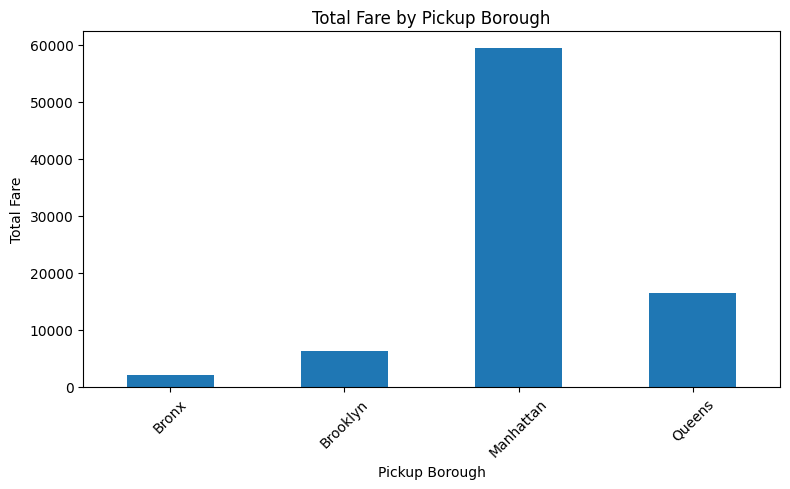

In [12]:
# BAR CHART

total_fare = df.groupby("pickup_borough")["fare"].sum()
plt.figure(figsize=(8, 5))
total_fare.plot(kind="bar")

plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.title("Total Fare by Pickup Borough")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


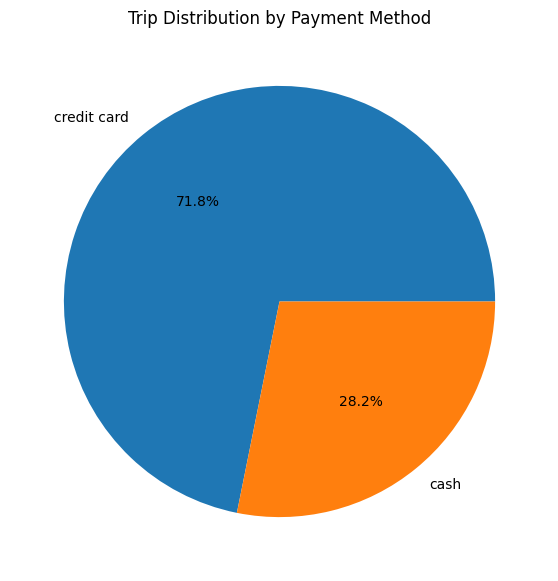

In [14]:
# PIE CHART

payment_counts = df["payment"].value_counts()
plt.figure(figsize=(7, 7))
payment_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Trip Distribution by Payment Method")

plt.show()


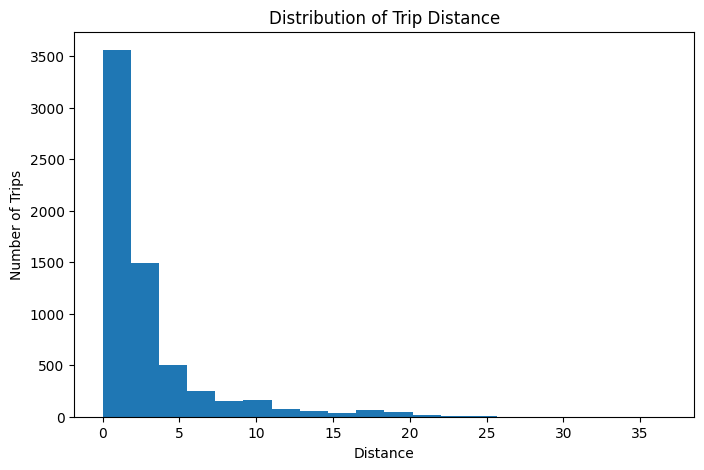

In [15]:
# HISTOGRAM

plt.figure(figsize=(8, 5))

plt.hist(df["distance"], bins=20)

plt.xlabel("Distance")
plt.ylabel("Number of Trips")
plt.title("Distribution of Trip Distance")

plt.show()


<Figure size 1000x600 with 0 Axes>

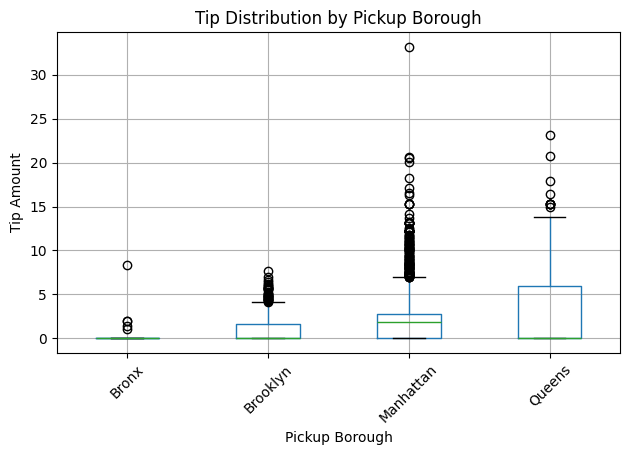

In [16]:
# BOX PLOT
plt.figure(figsize=(10, 6))

df.boxplot(
    column="tip",
    by="pickup_borough"
)

plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")
plt.title("Tip Distribution by Pickup Borough")

plt.suptitle("")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


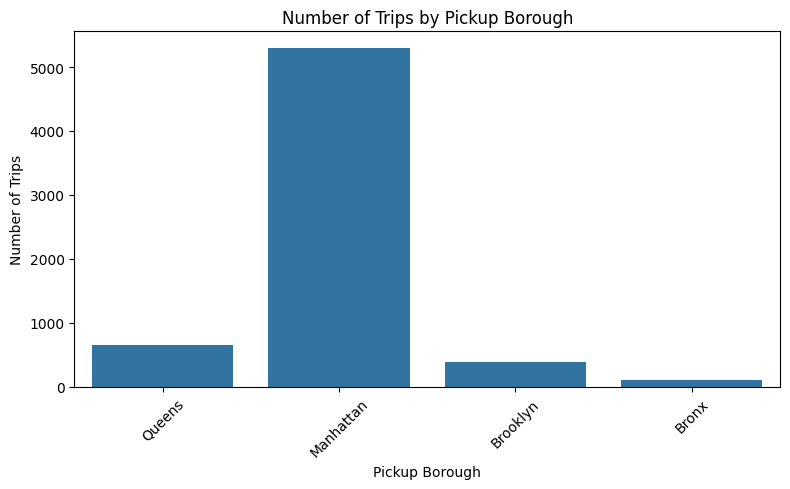

In [17]:
# STEP 4: VISUALIZATIONS USING SEABORN
import seaborn as sns
import matplotlib.pyplot as plt

# COUNT PLOT

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="pickup_borough"
)

plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")
plt.title("Number of Trips by Pickup Borough")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


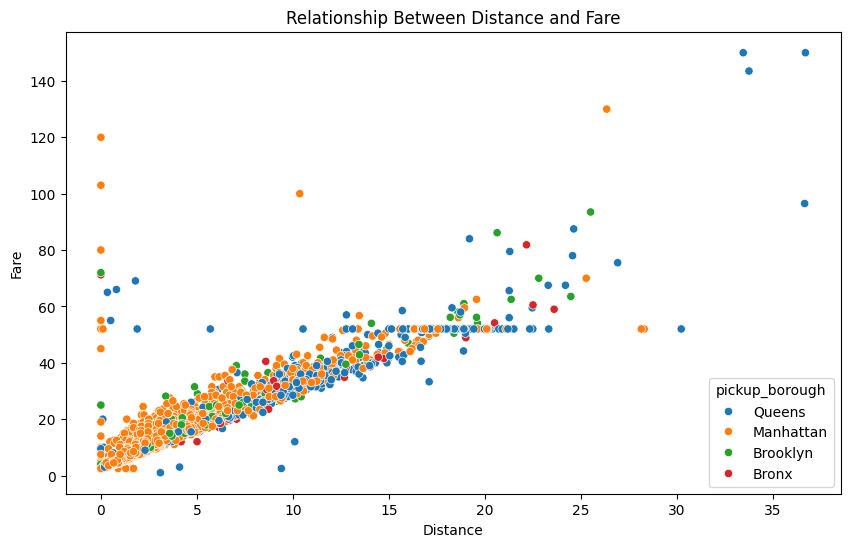

In [18]:
# SCATTER PLOT
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="distance",
    y="fare",
    hue="pickup_borough"
)

plt.xlabel("Distance")
plt.ylabel("Fare")
plt.title("Relationship Between Distance and Fare")

plt.show()


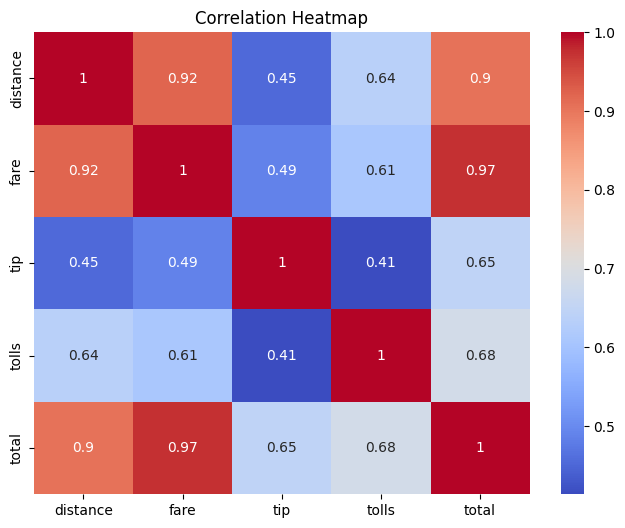

In [19]:
# HEATMAP
numeric_data = df[
    ["distance", "fare", "tip", "tolls", "total"]
]
correlation = numeric_data.corr()
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()


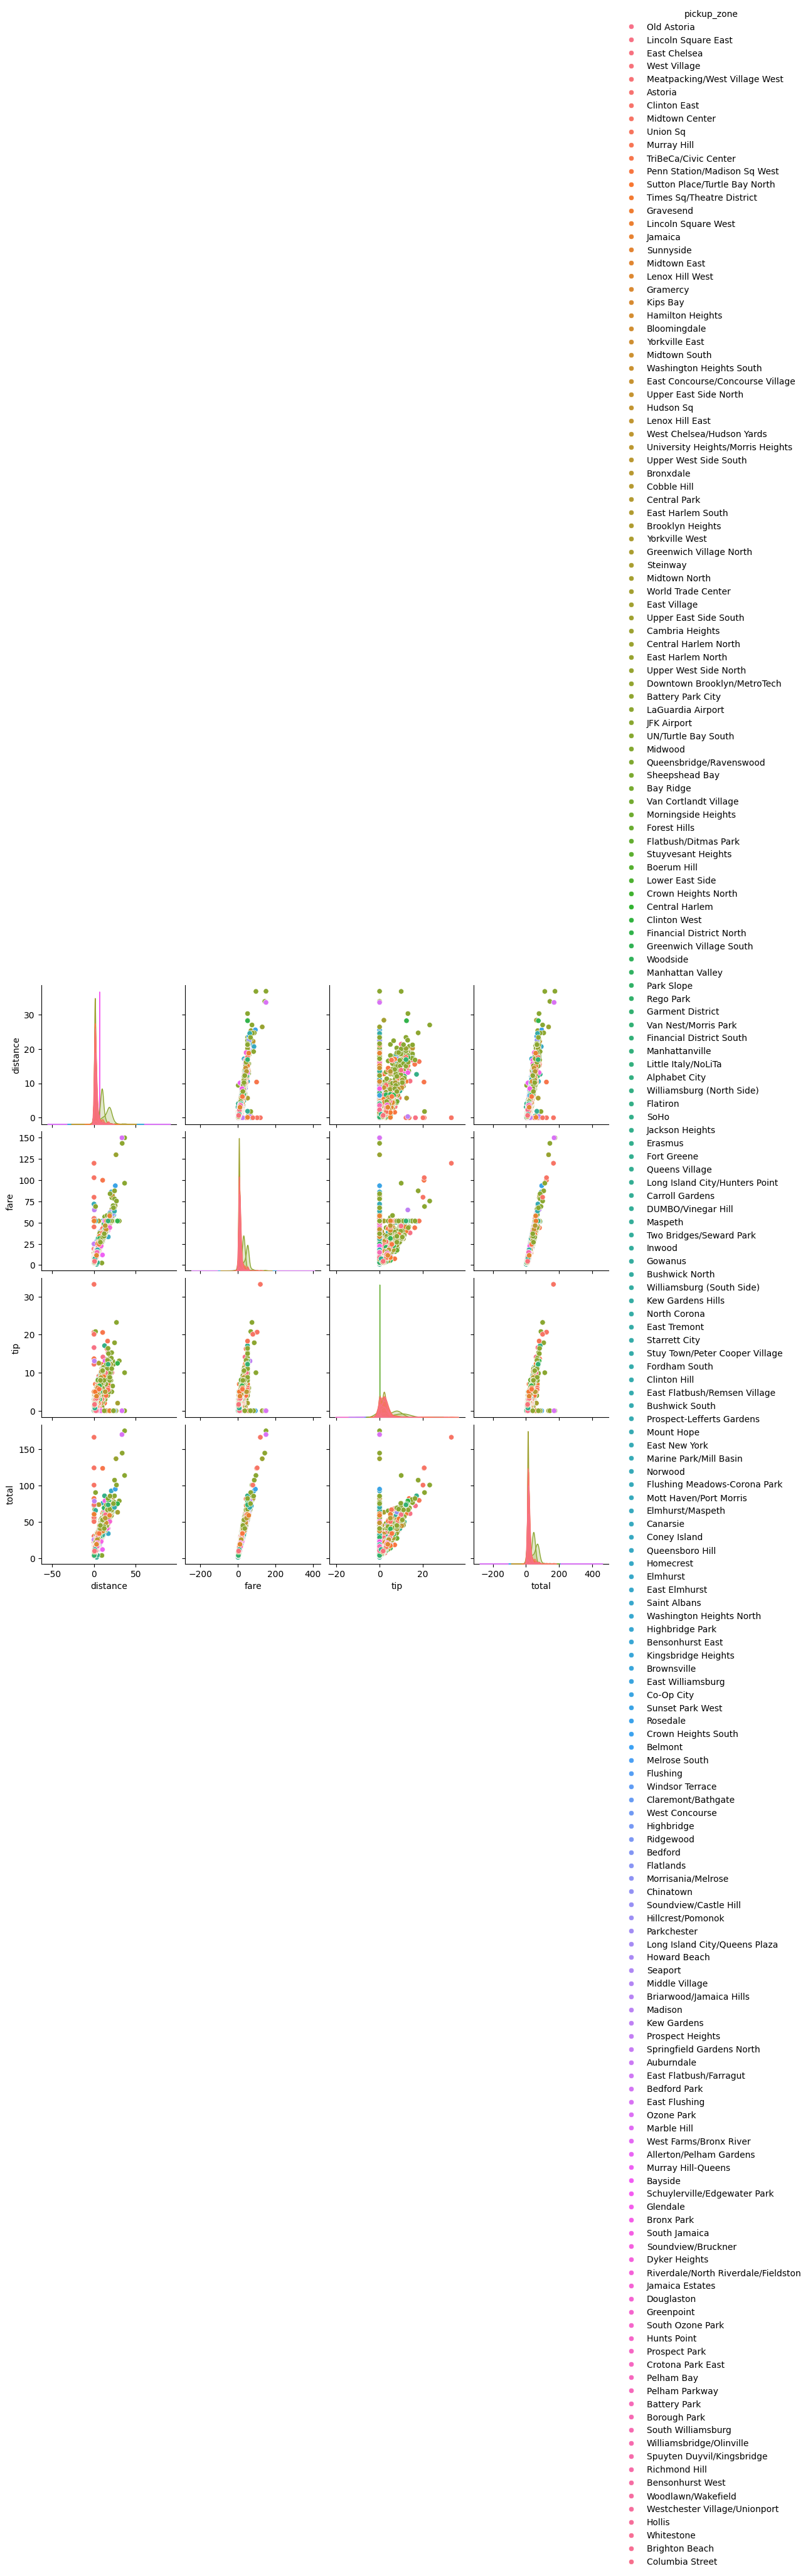

In [20]:
# PAIR PLOT

pair_data = df[
    ["distance", "fare", "tip", "total", "pickup_zone"]
].dropna()

sns.pairplot(
    pair_data,
    vars=["distance", "fare", "tip", "total"],
    hue="pickup_zone"
)

plt.show()


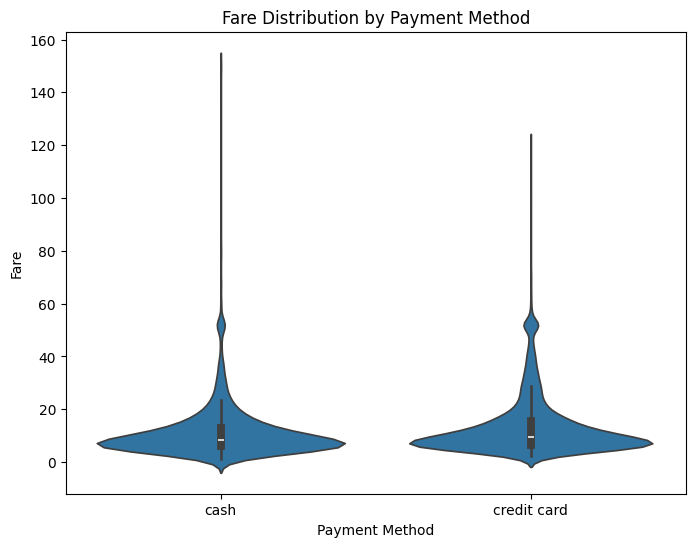

In [21]:
# VIOLIN PLOT
plt.figure(figsize=(8, 6))

sns.violinplot(
    data=df,
    x="payment",
    y="fare"
)

plt.xlabel("Payment Method")
plt.ylabel("Fare")
plt.title("Fare Distribution by Payment Method")

plt.show()
